# Aegis — Document Classification + OOD Detection (AG News)

Notebook này triển khai đầy đủ pipeline theo sơ đồ:

```
AG NEWS -> Data Preparation -> [TF-IDF+SVM Baseline | RoBERTa Final Model]
        -> Validation F1 (2 nhánh) -> Model Comparison -> RoBERTa
        -> [Classification (4 classes) | OOD (MSP / Energy)] -> Anomaly Alert
```

**Runtime:** Google Colab, GPU **L4** (Runtime > Change runtime type > GPU > L4).

**Nội dung:**
- Phase 1: Dataset (AG News, EDA, split)
- Phase 2: Baseline TF-IDF + Linear SVM
- Phase 3: Fine-tune RoBERTa-base
- Phase 4: OOD Detection (MSP + Energy)
- Phase 5 (bonus, file riêng): API + Dockerfile để triển khai

> **Lưu ý quan trọng về OOD:** AG News chỉ có 4 class nội dung tin tức hợp lệ,
> **không** có nhãn "anomaly". Vì business requirement của Aegis là bắt
> **quảng cáo / spam / nội dung độc hại lọt qua bộ lọc**, notebook này dùng
> 2 nguồn OOD proxy công khai, dễ tải qua `datasets`:
> - `sms_spam` → đại diện cho **spam / quảng cáo**
> - `tweet_eval` (subset `hate`) → đại diện cho **nội dung độc hại**

### Giải thích code cho từng cell

## 0. Setup
Cài đặt hoặc cập nhật các thư viện Python cần thiết cho dự án. Các thư viện này bao gồm `transformers`, `datasets`, `evaluate`, `accelerate`, `scikit-learn`, `matplotlib`, và `seaborn`.

In [1]:
# Cài đặt thư viện (Colab đã có sẵn hầu hết, chỉ cần cập nhật vài package)
!pip install -q -U transformers datasets evaluate accelerate scikit-learn matplotlib seaborn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 139.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 559.1/559.1 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 143.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 137.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 50.4 MB/s eta 0:00:00


Import tất cả các thư viện Python sẽ được sử dụng, bao gồm các thư viện cho xử lý dữ liệu (`numpy`, `pandas`), vẽ biểu đồ (`matplotlib`, `seaborn`), học máy (`torch`, `datasets`, `sklearn`), và transformers (`transformers`).

Cấu hình biến toàn cục `SEED` để đảm bảo tính tái lập của kết quả, kiểm tra và hiển thị thiết bị tính toán (`gpu`), và tạo thư mục đầu ra `OUTPUT_DIR` để lưu trữ các tạo phẩm của mô hình.

In [3]:
import os, json, random, time, warnings
warnings.filterwarnings("ignore")
import re # Added for advanced text cleaning

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch.utils.data import DataLoader

from datasets import load_dataset, Dataset, DatasetDict, concatenate_datasets

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split, GridSearchCV # Added GridSearchCV
from sklearn.metrics import (
    classification_report, f1_score, confusion_matrix,
    roc_auc_score, roc_curve
)

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback,
    DataCollatorWithPadding
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)
if device == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

OUTPUT_DIR = "/content/aegis_artifacts"
os.makedirs(OUTPUT_DIR, exist_ok=True)


Device: cuda
GPU: NVIDIA L4


## Phase 1 — Dataset

### 1. Chọn AG News
Sử dụng thư viện `datasets` để tải tập dữ liệu `ag_news`. Đây là một tập dữ liệu phân loại văn bản gồm 4 loại tin tức chính (World, Sports, Business, Sci/Tech). Sau đó in cấu trúc của tập dữ liệu và danh sách các nhãn (classes) có sẵn

In [5]:
raw = load_dataset("fancyzhx/ag_news")
print(raw)

LABEL_NAMES = raw["train"].features["label"].names
print("Classes:", LABEL_NAMES)  # ['World', 'Sports', 'Business', 'Sci/Tech']
NUM_LABELS = len(LABEL_NAMES)

README.md:   0%|          | 0.00/8.07k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 18.6MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.23MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
Classes: ['World', 'Sports', 'Business', 'Sci/Tech']


### 2. EDA
Tìm hiểu cấu trúc và đặc điểm của dữ liệu

                                                text  label  n_words
0  Wall St. Bears Claw Back Into the Black (Reute...      2       21
1  Carlyle Looks Toward Commercial Aerospace (Reu...      2       36
2  Oil and Economy Cloud Stocks' Outlook (Reuters...      2       36
3  Iraq Halts Oil Exports from Main Southern Pipe...      2       36
4  Oil prices soar to all-time record, posing new...      2       37

Train size: 120000 | Test size: 7600

Text length stats (words):
count    120000.000000
mean         37.847450
std          10.085245
min           8.000000
25%          32.000000
50%          37.000000
75%          43.000000
max         177.000000
Name: n_words, dtype: float64


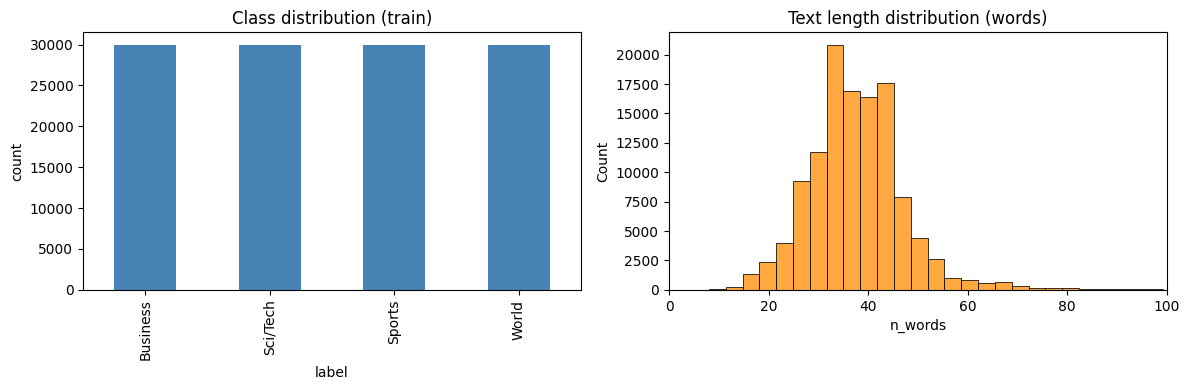

In [6]:
train_df = raw["train"].to_pandas()
test_df = raw["test"].to_pandas()

train_df["n_words"] = train_df["text"].str.split().apply(len)

print(train_df.head())
print("\nTrain size:", len(train_df), "| Test size:", len(test_df))
print("\nText length stats (words):")
print(train_df["n_words"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df["label"].map(dict(enumerate(LABEL_NAMES))).value_counts().plot(
    kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Class distribution (train)")
axes[0].set_ylabel("count")

sns.histplot(train_df["n_words"], bins=50, ax=axes[1], color="darkorange")
axes[1].set_title("Text length distribution (words)")
axes[1].set_xlim(0, 100)
plt.tight_layout()
plt.show()


**Phân phối các lớp**

- Cả 4 class (Business, Sci/Tech, Sports, World) đều có đúng 30,000 mẫu trong tập train (120,000/4) => AG News đã được chọn lọc/downsample để cân bằng tuyệt đối.
- Không cần các kỹ thuật xử lý imbalance (class weighting, oversampling, focal loss...).

**Độ dài văn bản**
- Văn bản khá đồng đều về độ dài, không có văn bản rỗng, chiều dài trung bình trung bình từ 37.8 từ, ngắn nhất là 8 từ, độ lệch chuẩn khoảng 10 từ, ít outlier.

- Phân phối lệch phải nhẹ (median 37, mean 37.8, max 177) nhưng toàn bộ nằm trong khoảng 20-60 từ

Dữ liệu của AG News cân bằng hoàn hảo, văn bản ngắn gọn đồng đều nhưng không phản ánh đúng độ khó của dữ liệu thực tế production (thường lệch class, câu dài ngắn thất thường, nhiễu, đa ngôn ngữ...).

### 3. Kiểm tra class distribution
Kiểm tra sự cân bằng của các lớp trong cả tập huấn luyện và tập kiểm tra bằng cách in ra tỷ lệ phần trăm của mỗi lớp


In [7]:
print("Class balance (train):")
print(train_df["label"].value_counts(normalize=True).sort_index())
print("\nClass balance (test):")
print(test_df["label"].value_counts(normalize=True).sort_index())


Class balance (train):
label
0    0.25
1    0.25
2    0.25
3    0.25
Name: proportion, dtype: float64

Class balance (test):
label
0    0.25
1    0.25
2    0.25
3    0.25
Name: proportion, dtype: float64


AG News được thiết kế cân bằng tuyệt đối giữa 4 class, mỗi class 25% -> không cần resample.

### 4. Train / Validation / Test split

AG News chỉ cung cấp tập `train` và `test`. Thực hiện `stratify` dựa trên nhãn (`label`), chia tập train thành 2 phần: 90% cho huấn luyện (`train_split`) và 10% cho validation (`val_split`) để đảm bảo tỷ lệ các lớp được giữ nguyên trong tập validation.

In [8]:
train_idx, val_idx = train_test_split(
    np.arange(len(train_df)),
    test_size=0.10,
    stratify=train_df["label"],
    random_state=SEED,
)

train_split = raw["train"].select(train_idx)
val_split = raw["train"].select(val_idx)
test_split = raw["test"]

dataset = DatasetDict({
    "train": train_split,
    "validation": val_split,
    "test": test_split,
})
print(dataset)


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 108000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 12000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})


## Phase 2 — Baseline: TF-IDF + Linear SVM

### 5. TF-IDF preprocessing
Chuẩn bị dữ liệu văn bản cho mô hình TF-IDF + Linear SVM

In [1]:
#Loại bỏ các ký tự đặc biệt và chuẩn hóa văn bản
def clean_text(text: str) -> str:
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove special characters (keep letters and spaces)
    text = re.sub(r'[^a-z\s]', '', text)
    # Replace multiple spaces with a single space
    text = re.sub(r'\s+', ' ', text).strip()
    return text

X_train_text = [clean_text(t) for t in dataset["train"]["text"]]
y_train = np.array(dataset["train"]["label"])

X_val_text = [clean_text(t) for t in dataset["validation"]["text"]]
y_val = np.array(dataset["validation"]["label"])

X_test_text = [clean_text(t) for t in dataset["test"]["text"]]
y_test = np.array(dataset["test"]["label"])

#Chuyển đổi văn bản thành biểu diễn TF-IDF
tfidf = TfidfVectorizer(
    max_features=50_000, #Giới hạn 50.000 đặc trưng
    ngram_range=(1, 2),
    sublinear_tf=True,
    stop_words="english",
)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf = tfidf.transform(X_val_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("TF-IDF matrix shape:", X_train_tfidf.shape)


NameError: name 'dataset' is not defined

### 6-7. Train Linear SVM + tune `C`

Tune `C` bằng cách fit trên `train` và chọn theo **Macro F1 trên validation**
(đúng theo sơ đồ: `Validation F1` là tiêu chí so sánh model).

In [10]:
param_grid = {'C': [0.01, 0.03, 0.1, 0.3, 1.0, 3.0, 10.0]}
svm_model = LinearSVC(random_state=SEED, max_iter=5000)

# Sử dụng GridSearchCV để tìm C tốt nhất với 5-fold cross-validation trên tập huấn luyện
grid_search = GridSearchCV(
    svm_model,
    param_grid,
    cv=5, # 5-fold cross-validation
    scoring='f1_macro',
    n_jobs=-1, # Sử dụng tất cả các nhân CPU có sẵn
    verbose=1
)
grid_search.fit(X_train_tfidf, y_train)

best_svm = grid_search.best_estimator_
best_C = grid_search.best_params_['C']
print(f"\nBest C found by GridSearchCV: {best_C}")

# Đánh giá mô hình tốt nhất trên tập validation riêng biệt để so sánh công bằng với RoBERTa
val_pred = best_svm.predict(X_val_tfidf)
svm_val_macro_f1 = f1_score(y_val, val_pred, average="macro")
print(f"Macro F1 on validation set with best C: {svm_val_macro_f1:.4f}")

# Lưu trữ kết quả (điều chỉnh để phù hợp với output của GridSearchCV)
svm_results = []
for i, C_val in enumerate(param_grid['C']):
    # grid_search.cv_results_['mean_test_score'] chứa f1_macro trung bình qua các fold
    # Lưu ý: Đây là f1_macro trên tập huấn luyện qua CV, không phải trên tập validation tách riêng.
    svm_results.append({"C": C_val, "val_macro_f1": grid_search.cv_results_['mean_test_score'][i]})

svm_results_df = pd.DataFrame(svm_results).sort_values("val_macro_f1", ascending=False)
print(svm_results_df)


Fitting 5 folds for each of 7 candidates, totalling 35 fits

Best C found by GridSearchCV: 0.3
Macro F1 on validation set with best C: 0.9285
       C  val_macro_f1
3   0.30      0.923691
4   1.00      0.920892
2   0.10      0.920503
5   3.00      0.913430
1   0.03      0.911445
6  10.00      0.903153
0   0.01      0.901498


#### Cell `4g2vtshGHEtt` - Huấn luyện Linear SVM và điều chỉnh tham số `C`

Cell này thực hiện tìm kiếm siêu tham số cho mô hình `LinearSVC` (Support Vector Machine tuyến tính). Nó thử nghiệm với một lưới các giá trị `C` khác nhau (tham số điều chỉnh regularization) để tìm ra giá trị tối ưu.

Đối với mỗi giá trị `C`, một mô hình `LinearSVC` được huấn luyện trên dữ liệu TF-IDF của tập huấn luyện (`X_train_tfidf`, `y_train`). Sau đó, hiệu suất của mô hình được đánh giá bằng Macro F1-score trên tập validation (`X_val_tfidf`, `y_val`). Các kết quả được lưu trữ và giá trị `C` tốt nhất (dựa trên Macro F1 trên validation) được chọn.

### 8. Evaluate baseline trên Test Set

=== TF-IDF + Linear SVM — Test Set ===
Macro F1: 0.9259
              precision    recall  f1-score   support

       World       0.95      0.91      0.93      1900
      Sports       0.96      0.99      0.97      1900
    Business       0.90      0.89      0.90      1900
    Sci/Tech       0.90      0.91      0.91      1900

    accuracy                           0.93      7600
   macro avg       0.93      0.93      0.93      7600
weighted avg       0.93      0.93      0.93      7600



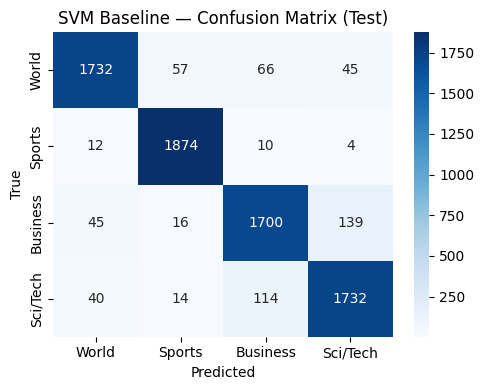

In [11]:
best_svm = LinearSVC(C=best_C, random_state=SEED, max_iter=5000)
best_svm.fit(X_train_tfidf, y_train)

test_pred_svm = best_svm.predict(X_test_tfidf)
svm_test_macro_f1 = f1_score(y_test, test_pred_svm, average="macro")

print("=== TF-IDF + Linear SVM — Test Set ===")
print("Macro F1:", round(svm_test_macro_f1, 4))
print(classification_report(y_test, test_pred_svm, target_names=LABEL_NAMES))

cm = confusion_matrix(y_test, test_pred_svm)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title("SVM Baseline — Confusion Matrix (Test)")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()


#### Cell `_jHsUa0iHEtu` - Đánh giá Baseline trên Test Set

Cell này đánh giá mô hình `LinearSVC` tốt nhất (với giá trị `C` đã tìm được ở bước trước) trên tập kiểm tra độc lập. Mô hình được huấn luyện lại trên toàn bộ tập huấn luyện với `best_C`.

Sau đó, nó tính toán và in ra:
- Macro F1-score trên tập kiểm tra.
- `classification_report` chi tiết bao gồm precision, recall, f1-score và support cho mỗi lớp.
- Biểu đồ ma trận nhầm lẫn (`confusion_matrix`) để trực quan hóa hiệu suất phân loại của mô hình trên tập kiểm tra.

### 9. Lưu kết quả baseline

In [12]:
import joblib

os.makedirs(f"{OUTPUT_DIR}/baseline", exist_ok=True)
joblib.dump(tfidf, f"{OUTPUT_DIR}/baseline/tfidf_vectorizer.joblib")
joblib.dump(best_svm, f"{OUTPUT_DIR}/baseline/svm_model.joblib")

baseline_report = {
    "model": "TF-IDF + LinearSVC",
    "best_C": float(best_C),
    "val_macro_f1_by_C": svm_results,
    "test_macro_f1": float(svm_test_macro_f1),
    "test_classification_report": classification_report(
        y_test, test_pred_svm, target_names=LABEL_NAMES, output_dict=True
    ),
}
with open(f"{OUTPUT_DIR}/baseline/baseline_results.json", "w") as f:
    json.dump(baseline_report, f, indent=2)

print("Saved baseline artifacts to", f"{OUTPUT_DIR}/baseline")


Saved baseline artifacts to /content/aegis_artifacts/baseline


#### Cell `kJYrAWq9HEtu` - Lưu kết quả Baseline

Cell này lưu trữ các tạo phẩm của mô hình baseline (TF-IDF + Linear SVM). Nó sử dụng thư viện `joblib` để lưu vectorizer TF-IDF đã được huấn luyện và mô hình SVM tốt nhất vào thư mục `OUTPUT_DIR/baseline`.

Ngoài ra, một báo cáo tóm tắt các kết quả của baseline, bao gồm `best_C`, Macro F1 trên validation và test, và `classification_report` chi tiết, được lưu dưới dạng tệp JSON (`baseline_results.json`).

## Phase 3 — Transformer (RoBERTa)

### 10. Load RoBERTa-base

In [13]:
MODEL_NAME = "roberta-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=NUM_LABELS
).to(device)


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  499MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


#### Cell `oq8g_-RMHEtu` - Tải mô hình RoBERTa-base

Cell này khởi tạo tokenizer và mô hình `AutoModelForSequenceClassification` từ `roberta-base` được huấn luyện trước. `tokenizer` sẽ chuyển đổi văn bản thành các token ID mà mô hình hiểu được, và `model` là mô hình Transformer được cấu hình để phân loại sequence với số lượng nhãn bằng `NUM_LABELS` (4 trong trường hợp này). Mô hình sau đó được chuyển lên thiết bị GPU (`cuda`) nếu có.

### 11. Tokenization

In [14]:
MAX_LEN = 128  # AG News: tiêu đề + mô tả ngắn, 128 token là đủ

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LEN)

tokenized = dataset.map(tokenize_fn, batched=True, remove_columns=["text"])
tokenized = tokenized.rename_column("label", "labels")
tokenized.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


Map:   0%|          | 0/108000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

#### Cell `5Eejo9ryHEtu` - Tokenization

Cell này chuẩn bị dữ liệu văn bản cho mô hình RoBERTa. Nó định nghĩa hàm `tokenize_fn` để token hóa văn bản bằng `tokenizer` đã tải, với `truncation=True` và `max_length=MAX_LEN` (128 token) để xử lý các văn bản dài hơn. Sau đó, hàm này được áp dụng cho toàn bộ tập dữ liệu (`dataset.map`).

Các cột không cần thiết (`text`) được loại bỏ và cột `label` được đổi tên thành `labels` để phù hợp với yêu cầu của `transformers`. Dữ liệu được đặt định dạng `torch` và chỉ giữ lại các cột `input_ids`, `attention_mask`, và `labels`. Cuối cùng, `DataCollatorWithPadding` được tạo để tự động thêm padding vào các batch có độ dài khác nhau.

### 12-13. Fine-tuning + Tune hyperparameters

Để tiết kiệm thời gian trên L4, ta thử một lưới nhỏ (learning rate x batch size)
với **1 epoch** mỗi cấu hình, chọn cấu hình tốt nhất theo **Validation Macro F1**,
rồi train lại full epochs với cấu hình đó.

In [16]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "macro_f1": f1_score(labels, preds, average="macro"),
        "accuracy": (preds == labels).mean(),
    }

hp_grid = [
    {"lr": 2e-5, "bs": 32},
    {"lr": 3e-5, "bs": 32},
    {"lr": 2e-5, "bs": 16},
]

hp_search_results = []

for i, hp in enumerate(hp_grid):
    print(f"\n=== HP search {i+1}/{len(hp_grid)}: lr={hp['lr']} bs={hp['bs']} ===")
    trial_model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=NUM_LABELS
    ).to(device)

    args = TrainingArguments(
        output_dir=f"/content/hp_search_{i}",
        per_device_train_batch_size=hp["bs"],
        per_device_eval_batch_size=64,
        learning_rate=hp["lr"],
        num_train_epochs=1,
        weight_decay=0.01,
        eval_strategy="epoch",
        save_strategy="no",
        logging_steps=200,
        fp16=torch.cuda.is_available(),
        report_to="none",
        seed=SEED,
    )

    trainer = Trainer(
        model=trial_model,
        args=args,
        train_dataset=tokenized["train"],
        eval_dataset=tokenized["validation"],
        # tokenizer=tokenizer, # This argument is no longer needed here
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
    trainer.train()
    metrics = trainer.evaluate()
    hp_search_results.append({**hp, "val_macro_f1": metrics["eval_macro_f1"]})
    print(hp, "-> val_macro_f1 =", metrics["eval_macro_f1"])

    del trainer, trial_model
    torch.cuda.empty_cache()

hp_search_df = pd.DataFrame(hp_search_results).sort_values("val_macro_f1", ascending=False)
print(hp_search_df)
best_hp = hp_search_df.iloc[0].to_dict()
print("\nBest hyperparameters:", best_hp)



=== HP search 1/3: lr=2e-05 bs=32 ===


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.165516,0.162441,0.945416,0.945417


Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
0.165516,0.162441,1,0.945416,0.945417


...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.bias         | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.out_proj.bias   | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.weight | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.175162,0.182889,0.945389,0.945417


Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
0.175162,0.182889,1,0.945389,0.945417


{'lr': 2e-05, 'bs': 16} -> val_macro_f1 = 0.9453885211631745
        lr  bs  val_macro_f1
1  0.00003  32      0.946424
0  0.00002  32      0.945416
2  0.00002  16      0.945389

Best hyperparameters: {'lr': 3e-05, 'bs': 32.0, 'val_macro_f1': 0.946423795833963}


#### Cell `MmY21f04HEtv` - Điều chỉnh siêu tham số cho RoBERTa (Hyperparameter Tuning)

Cell này thực hiện tìm kiếm siêu tham số cho mô hình RoBERTa. Nó định nghĩa hàm `compute_metrics` để tính toán Macro F1-score và Accuracy, đây là các metric được sử dụng để đánh giá mô hình.

Một lưới các siêu tham số (`hp_grid`) được định nghĩa, bao gồm các sự kết hợp khác nhau của learning rate (`lr`) và batch size (`bs`). Đối với mỗi cấu hình siêu tham số, một mô hình RoBERTa mới được khởi tạo và một `Trainer` được thiết lập với các đối số huấn luyện tương ứng. Mô hình được huấn luyện trong 1 epoch, và hiệu suất trên tập validation được đánh giá. Các kết quả (Macro F1 trên validation) được lưu lại và cấu hình siêu tham số tốt nhất được chọn.

Sau mỗi lần thử nghiệm, bộ nhớ GPU được giải phóng (`del trainer, trial_model; torch.cuda.empty_cache()`) để tránh lỗi Out-of-Memory.

### 14. Train final model + chọn best checkpoint bằng Validation Macro F1

`load_best_model_at_end=True` + `metric_for_best_model="macro_f1"` +
`EarlyStoppingCallback` đảm bảo checkpoint cuối cùng luôn là checkpoint có
Macro F1 tốt nhất trên validation, không phải checkpoint cuối cùng theo step.

In [20]:
FINAL_EPOCHS = 4  # early stopping sẽ dừng sớm nếu không cải thiện

final_args = TrainingArguments(
    output_dir=f"{OUTPUT_DIR}/roberta_checkpoints",
    per_device_train_batch_size=int(best_hp["bs"]),
    per_device_eval_batch_size=64,
    learning_rate=float(best_hp["lr"]),
    num_train_epochs=FINAL_EPOCHS,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=200,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=model,
    args=final_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)

trainer.train()
print("\nBest validation macro F1:", trainer.state.best_metric)


Epoch,Training Loss,Validation Loss,Macro F1,Accuracy
1,0.183721,0.169452,0.944013,0.944000
2,0.139483,0.179646,0.946242,0.946167
3,0.104413,0.181768,0.951076,0.951083
4,0.084464,0.208702,0.949685,0.949667


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Best validation macro F1: 0.951075791650752


#### Cell `fHisMf5SHEtv` - Huấn luyện mô hình cuối cùng với Early Stopping

Cell này huấn luyện mô hình RoBERTa cuối cùng với các siêu tham số tốt nhất đã tìm được. Các đối số huấn luyện (`TrainingArguments`) được cấu hình, bao gồm:
- `output_dir`: Thư mục lưu checkpoint của mô hình.
- `per_device_train_batch_size`, `per_device_eval_batch_size`, `learning_rate`, `num_train_epochs`, `weight_decay`, `warmup_ratio`: Các siêu tham số đã được tối ưu.
- `eval_strategy`, `save_strategy`: Đánh giá và lưu mô hình theo từng epoch.
- `save_total_limit`: Giới hạn số lượng checkpoint được lưu.
- `load_best_model_at_end=True`, `metric_for_best_model="macro_f1"`, `greater_is_better=True`: Đảm bảo rằng checkpoint có Macro F1-score tốt nhất trên validation sẽ được tải lại vào cuối quá trình huấn luyện.
- `EarlyStoppingCallback`: Một callback được sử dụng để dừng huấn luyện sớm nếu Macro F1-score trên validation không cải thiện sau một số lượng epoch nhất định (`early_stopping_patience=1`).

Mô hình được huấn luyện sử dụng `trainer.train()`, và Macro F1 tốt nhất trên validation được in ra.

### 15. Evaluate trên Test Set

Training Loss,Validation Loss,Epoch,Macro F1,Accuracy
0.084464,0.180025,4,0.951739,0.951711


=== RoBERTa — Test Set ===
{'eval_loss': 0.18002541363239288, 'eval_macro_f1': 0.9517386025589567, 'eval_accuracy': 0.9517105263157895}



Macro F1: 0.9517
              precision    recall  f1-score   support

       World       0.97      0.95      0.96      1900
      Sports       0.99      0.99      0.99      1900
    Business       0.93      0.92      0.93      1900
    Sci/Tech       0.92      0.94      0.93      1900

    accuracy                           0.95      7600
   macro avg       0.95      0.95      0.95      7600
weighted avg       0.95      0.95      0.95      7600



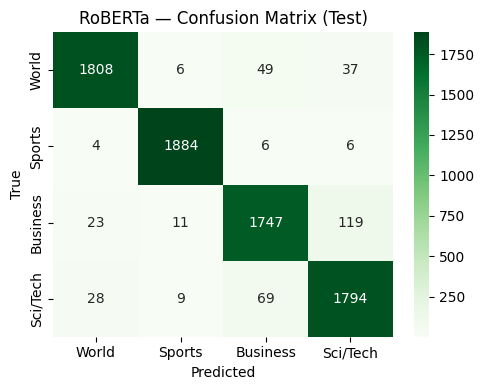

In [21]:
test_metrics = trainer.evaluate(tokenized["test"])
print("=== RoBERTa — Test Set ===")
print(test_metrics)

test_preds_output = trainer.predict(tokenized["test"])
roberta_test_logits = test_preds_output.predictions
roberta_test_pred = np.argmax(roberta_test_logits, axis=-1)
roberta_test_labels = test_preds_output.label_ids

roberta_test_macro_f1 = f1_score(roberta_test_labels, roberta_test_pred, average="macro")
print("\nMacro F1:", round(roberta_test_macro_f1, 4))
print(classification_report(roberta_test_labels, roberta_test_pred, target_names=LABEL_NAMES))

cm = confusion_matrix(roberta_test_labels, roberta_test_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title("RoBERTa — Confusion Matrix (Test)")
plt.ylabel("True"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()


#### Cell `jJB1T8F6HEtv` - Đánh giá RoBERTa trên Test Set

Cell này đánh giá hiệu suất của mô hình RoBERTa đã huấn luyện trên tập kiểm tra. Nó sử dụng `trainer.evaluate()` để tính toán các metric trên tập kiểm tra và in ra kết quả.

Sau đó, nó sử dụng `trainer.predict()` để lấy `logits` (output thô của mô hình trước khi softmax) và các nhãn thực từ tập kiểm tra. Từ `logits`, nó tính toán các dự đoán (`roberta_test_pred`).

Cuối cùng, nó tính toán và in ra:
- Macro F1-score trên tập kiểm tra.
- `classification_report` chi tiết.
- Biểu đồ ma trận nhầm lẫn (`confusion_matrix`) để trực quan hóa hiệu suất phân loại của mô hình RoBERTa trên tập kiểm tra.

## Model Comparison

So sánh 2 model theo **Validation Macro F1** (đúng nhánh hội tụ trong sơ đồ)
và Test Macro F1 để tham khảo.

In [22]:
svm_val_best = svm_results_df.iloc[0]["val_macro_f1"]
roberta_val_best = trainer.state.best_metric

comparison_df = pd.DataFrame([
    {"model": "TF-IDF + Linear SVM", "val_macro_f1": svm_val_best, "test_macro_f1": svm_test_macro_f1},
    {"model": "RoBERTa-base", "val_macro_f1": roberta_val_best, "test_macro_f1": roberta_test_macro_f1},
])
print(comparison_df)

winner = comparison_df.sort_values("val_macro_f1", ascending=False).iloc[0]["model"]
print(f"\n>>> Model được chọn theo Validation Macro F1: {winner}")

comparison_df.to_json(f"{OUTPUT_DIR}/model_comparison.json", orient="records", indent=2)


                 model  val_macro_f1  test_macro_f1
0  TF-IDF + Linear SVM      0.923691       0.925893
1         RoBERTa-base      0.951076       0.951739

>>> Model được chọn theo Validation Macro F1: RoBERTa-base


#### Cell `CwXaiX3GHEtv` - So sánh Mô hình (TF-IDF + SVM vs. RoBERTa)

Cell này tổng hợp và so sánh hiệu suất của hai mô hình: TF-IDF + Linear SVM và RoBERTa-base. Nó tạo một DataFrame chứa Macro F1-score trên cả tập validation (tiêu chí chính để chọn mô hình) và tập test cho cả hai mô hình.

Nó in ra DataFrame so sánh và xác định mô hình chiến thắng dựa trên Macro F1-score cao nhất trên validation. Cuối cùng, kết quả so sánh được lưu vào tệp JSON (`model_comparison.json`).

Ghi chú: theo sơ đồ, sau bước *Model Comparison*, **RoBERTa** đi tiếp vào
2 nhánh: `Classification (4 classes)` — đã evaluate ở trên — và `OOD (MSP/Energy)`.
Từ đây về sau, notebook dùng model RoBERTa vừa fine-tune.

## Phase 4 — OOD Detection

### 16. Chuẩn bị anomaly / OOD dataset

Business requirement của Aegis: bắt **quảng cáo / spam / nội dung độc hại
lọt qua bộ lọc**. Ta dùng 2 dataset proxy công khai để mô phỏng 2 loại
anomaly này:

- `sms_spam` (UCI SMS Spam Collection) → proxy cho **spam / quảng cáo**
- `tweet_eval` subset `hate` (nhãn `1` = hateful) → proxy cho **nội dung độc hại**

Cả hai được gộp lại thành tập **OOD**, dùng nhãn nhị phân: `0 = ID (AG News)`,
`1 = OOD (spam/toxic)`.

In [30]:
sms = load_dataset("ucirvine/sms_spam")["train"]
sms_spam_texts = [t for t, l in zip(sms["sms"], sms["label"]) if l == 1]  # 1 = spam

# --- Toxic proxy ---
tweet_hate = load_dataset("cardiffnlp/tweet_eval", "hate")
hate_texts = [
    t for t, l in zip(tweet_hate["train"]["text"], tweet_hate["train"]["label"]) if l == 1
]  # 1 = hateful

ood_texts_all = sms_spam_texts + hate_texts
print("Spam proxy samples:", len(sms_spam_texts))
print("Toxic proxy samples:", len(hate_texts))
print("Total OOD samples:", len(ood_texts_all))

# Split OOD thành val / test (để tune threshold trên val, đánh giá cuối trên test)
ood_val_texts, ood_test_texts = train_test_split(
    ood_texts_all, test_size=0.5, random_state=SEED
)
print("OOD val:", len(ood_val_texts), "| OOD test:", len(ood_test_texts))

README.md:   0%|          | 0.00/4.98k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  359kB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5574 [00:00<?, ? examples/s]

README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

...

hate/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/9000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2970 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Spam proxy samples: 747
Toxic proxy samples: 3783
Total OOD samples: 4530
OOD val: 2265 | OOD test: 2265


#### Cell `-71Frw-8HEtv` - Chuẩn bị tập dữ liệu OOD (Out-of-Distribution)

Cell này chuẩn bị dữ liệu cho việc phát hiện OOD. Nó tải hai tập dữ liệu công khai làm proxy cho dữ liệu OOD:
- `sms_spam`: Để đại diện cho spam/quảng cáo.
- `tweet_eval` (subset `hate`): Để đại diện cho nội dung độc hại.

Nó trích xuất các văn bản spam và hate từ các tập dữ liệu này và gộp chúng lại thành `ood_texts_all`. Sau đó, `ood_texts_all` được chia thành `ood_val_texts` và `ood_test_texts` để điều chỉnh ngưỡng OOD trên validation và đánh giá cuối cùng trên test.

### 17-18. Implement MSP + tune threshold trên validation

In [31]:
model.eval()

@torch.no_grad()
def get_logits(texts, batch_size=64):
    all_logits = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]
        enc = tokenizer(batch, truncation=True, max_length=MAX_LEN,
                         padding=True, return_tensors="pt").to(device)
        out = model(**enc)
        all_logits.append(out.logits.cpu().numpy())
    return np.concatenate(all_logits, axis=0)

def msp_score(logits):
    # Maximum Softmax Probability: score cao = tự tin = nhiều khả năng là ID
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
    return probs.max(axis=1)

# Logits cho ID validation (đã có sẵn từ RoBERTa) và OOD validation
id_val_logits = trainer.predict(tokenized["validation"]).predictions
ood_val_logits = get_logits(ood_val_texts)

id_val_msp = msp_score(id_val_logits)
ood_val_msp = msp_score(ood_val_logits)

# Nhãn: 1 = OOD, 0 = ID. Score dùng cho AUROC phải là "độ bất thường"
# nên ta dùng (1 - MSP) làm anomaly score.
y_val_ood_label = np.concatenate([np.zeros(len(id_val_msp)), np.ones(len(ood_val_msp))])
val_anomaly_score_msp = np.concatenate([1 - id_val_msp, 1 - ood_val_msp])

auroc_msp = roc_auc_score(y_val_ood_label, val_anomaly_score_msp)
print("MSP AUROC (validation):", round(auroc_msp, 4))

# Tune threshold để đạt OOD Recall >= 90% (theo yêu cầu business) với FPR thấp nhất có thể
fpr, tpr, thresholds = roc_curve(y_val_ood_label, val_anomaly_score_msp)
target_recall = 0.90
valid_idx = np.where(tpr >= target_recall)[0]
best_idx = valid_idx[np.argmin(fpr[valid_idx])] if len(valid_idx) else np.argmax(tpr)
msp_anomaly_threshold = thresholds[best_idx]

print(f"Chosen MSP anomaly-score threshold: {msp_anomaly_threshold:.4f}")
print(f"  -> Validation Recall (OOD): {tpr[best_idx]:.4f}")
print(f"  -> Validation FPR (ID flagged as OOD): {fpr[best_idx]:.4f}")


MSP AUROC (validation): 0.8057
Chosen MSP anomaly-score threshold: 0.0017
  -> Validation Recall (OOD): 0.9002
  -> Validation FPR (ID flagged as OOD): 0.4085


#### Cell `gG8Ang_WHEtv` - Triển khai MSP và điều chỉnh ngưỡng trên Validation

Cell này thực hiện phát hiện OOD bằng phương pháp **Maximum Softmax Probability (MSP)** và điều chỉnh ngưỡng trên tập validation.

- Hàm `get_logits` được định nghĩa để lấy `logits` từ mô hình RoBERTa cho một danh sách các văn bản.
- Hàm `msp_score` được định nghĩa để tính toán MSP từ `logits` (xác suất tối đa sau softmax).
- `id_val_logits` (từ AG News validation) và `ood_val_logits` (từ các proxy OOD validation) được tính toán.
- `id_val_msp` và `ood_val_msp` được suy ra.
- Nhãn OOD (`y_val_ood_label`: 0 cho ID, 1 cho OOD) và điểm bất thường (`val_anomaly_score_msp`: `1 - MSP` vì MSP cao = ID) được tạo.
- **AUROC** (`roc_auc_score`) được tính để đánh giá hiệu suất phân loại OOD.
- **Ngưỡng OOD** (`msp_anomaly_threshold`) được điều chỉnh dựa trên đường cong ROC (`roc_curve`) để đạt được `OOD Recall >= 90%` với `False Positive Rate (FPR)` thấp nhất trên tập validation. Các thông số này được in ra.

### 19. Evaluate OOD Recall (MSP) trên test

In [32]:
id_test_logits = roberta_test_logits  # đã có từ bước evaluate test set
ood_test_logits = get_logits(ood_test_texts)

id_test_msp = msp_score(id_test_logits)
ood_test_msp = msp_score(ood_test_logits)

id_test_anomaly = 1 - id_test_msp
ood_test_anomaly = 1 - ood_test_msp

id_flagged_as_ood = (id_test_anomaly >= msp_anomaly_threshold).mean()
ood_recall_msp = (ood_test_anomaly >= msp_anomaly_threshold).mean()

y_test_ood_label = np.concatenate([np.zeros(len(id_test_msp)), np.ones(len(ood_test_msp))])
test_anomaly_score_msp = np.concatenate([id_test_anomaly, ood_test_anomaly])
auroc_msp_test = roc_auc_score(y_test_ood_label, test_anomaly_score_msp)

print("=== MSP — OOD Detection (Test) ===")
print(f"OOD Recall: {ood_recall_msp:.4f}")
print(f"False Positive Rate (ID misflagged): {id_flagged_as_ood:.4f}")
print(f"AUROC: {auroc_msp_test:.4f}")


=== MSP — OOD Detection (Test) ===
OOD Recall: 0.9046
False Positive Rate (ID misflagged): 0.4134
AUROC: 0.8026


#### Cell `HvEh6p2pHEtw` - Đánh giá OOD Recall (MSP) trên Test Set

Cell này đánh giá hiệu suất của phương pháp MSP trên tập kiểm tra độc lập. Nó sử dụng `logits` từ tập kiểm tra AG News (ID) và tập kiểm tra OOD đã chuẩn bị trước đó.

- MSP scores (`id_test_msp`, `ood_test_msp`) và điểm bất thường (`id_test_anomaly`, `ood_test_anomaly`) được tính toán.
- **OOD Recall** (tỷ lệ OOD thực sự được gắn cờ là OOD) và **False Positive Rate (FPR)** (tỷ lệ ID bị gắn cờ sai là OOD) được tính dựa trên ngưỡng đã điều chỉnh.
- **AUROC** cũng được tính toán trên tập kiểm tra OOD.
- Tất cả các metric này được in ra để đánh giá tổng thể về khả năng phát hiện OOD của MSP.

### 20. Energy-based OOD (optional, đã implement)

Energy score: `E(x) = -T * logsumexp(logits / T)`. Energy **thấp** = ID,
**cao** = OOD (ngược hướng so với MSP, nên ta dùng thẳng Energy làm
anomaly score, không cần đảo dấu).

In [33]:
def energy_score(logits, T=1.0):
    logits_t = torch.tensor(logits) / T
    energy = -T * torch.logsumexp(logits_t, dim=-1)
    return energy.numpy()

T = 1.0
id_val_energy = energy_score(id_val_logits, T)
ood_val_energy = energy_score(ood_val_logits, T)

val_anomaly_score_energy = np.concatenate([id_val_energy, ood_val_energy])
auroc_energy_val = roc_auc_score(y_val_ood_label, val_anomaly_score_energy)
print("Energy AUROC (validation):", round(auroc_energy_val, 4))

fpr_e, tpr_e, thresholds_e = roc_curve(y_val_ood_label, val_anomaly_score_energy)
valid_idx_e = np.where(tpr_e >= target_recall)[0]
best_idx_e = valid_idx_e[np.argmin(fpr_e[valid_idx_e])] if len(valid_idx_e) else np.argmax(tpr_e)
energy_anomaly_threshold = thresholds_e[best_idx_e]

print(f"Chosen Energy anomaly-score threshold: {energy_anomaly_threshold:.4f}")
print(f"  -> Validation Recall (OOD): {tpr_e[best_idx_e]:.4f}")
print(f"  -> Validation FPR: {fpr_e[best_idx_e]:.4f}")

# Evaluate trên test
id_test_energy = energy_score(id_test_logits, T)
ood_test_energy = energy_score(ood_test_logits, T)

id_flagged_as_ood_energy = (id_test_energy >= energy_anomaly_threshold).mean()
ood_recall_energy = (ood_test_energy >= energy_anomaly_threshold).mean()

test_anomaly_score_energy = np.concatenate([id_test_energy, ood_test_energy])
auroc_energy_test = roc_auc_score(y_test_ood_label, test_anomaly_score_energy)

print("\n=== Energy — OOD Detection (Test) ===")
print(f"OOD Recall: {ood_recall_energy:.4f}")
print(f"False Positive Rate (ID misflagged): {id_flagged_as_ood_energy:.4f}")
print(f"AUROC: {auroc_energy_test:.4f}")


Energy AUROC (validation): 0.8611
Chosen Energy anomaly-score threshold: -5.6738
  -> Validation Recall (OOD): 0.9002
  -> Validation FPR: 0.3398

=== Energy — OOD Detection (Test) ===
OOD Recall: 0.8883
False Positive Rate (ID misflagged): 0.3501
AUROC: 0.8587


#### Cell `Te6l2qDdHEtw` - Energy-based OOD Detection

Cell này triển khai phương pháp phát hiện OOD dựa trên **Energy score**, một phương pháp thay thế cho MSP.

- Hàm `energy_score` được định nghĩa để tính toán Energy score từ `logits` và một tham số nhiệt độ `T`. Energy score thấp hơn cho ID và cao hơn cho OOD.
- Energy scores cho tập validation ID và OOD (`id_val_energy`, `ood_val_energy`) được tính toán.
- **AUROC** được tính cho Energy score trên validation.
- Tương tự như MSP, **ngưỡng OOD** (`energy_anomaly_threshold`) được điều chỉnh trên validation để đạt được `OOD Recall >= 90%` với FPR thấp nhất. Các thông số này được in ra.
- Cuối cùng, phương pháp Energy-based OOD được đánh giá trên tập kiểm tra, tính toán **OOD Recall, FPR, và AUROC** trên dữ liệu test tương tự như cách làm với MSP.

### 21. So sánh MSP vs Energy

   method     auroc  ood_recall       fpr
0     MSP  0.802593    0.904636  0.413421
1  Energy  0.858678    0.888300  0.350132


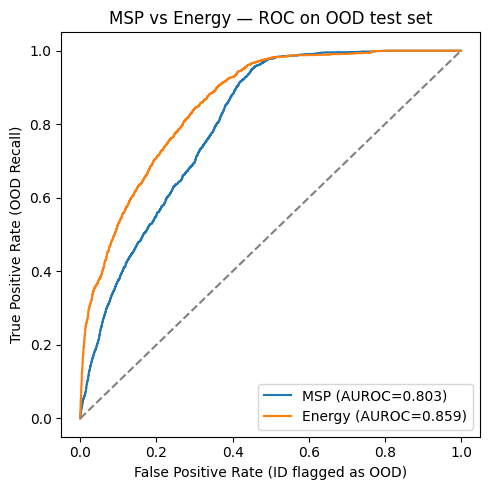

In [34]:
ood_comparison = pd.DataFrame([
    {"method": "MSP", "auroc": auroc_msp_test, "ood_recall": ood_recall_msp, "fpr": id_flagged_as_ood},
    {"method": "Energy", "auroc": auroc_energy_test, "ood_recall": ood_recall_energy, "fpr": id_flagged_as_ood_energy},
])
print(ood_comparison)

plt.figure(figsize=(5, 5))
fpr_m, tpr_m, _ = roc_curve(y_test_ood_label, test_anomaly_score_msp)
fpr_e2, tpr_e2, _ = roc_curve(y_test_ood_label, test_anomaly_score_energy)
plt.plot(fpr_m, tpr_m, label=f"MSP (AUROC={auroc_msp_test:.3f})")
plt.plot(fpr_e2, tpr_e2, label=f"Energy (AUROC={auroc_energy_test:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate (ID flagged as OOD)")
plt.ylabel("True Positive Rate (OOD Recall)")
plt.title("MSP vs Energy — ROC on OOD test set")
plt.legend()
plt.tight_layout()
plt.show()

ood_comparison.to_json(f"{OUTPUT_DIR}/ood_comparison.json", orient="records", indent=2)


#### Cell `jv3_rwB4HEtx` - So sánh MSP và Energy

Cell này so sánh trực quan và định lượng hai phương pháp phát hiện OOD (MSP và Energy).

- Một DataFrame (`ood_comparison`) được tạo để hiển thị AUROC, OOD Recall, và FPR trên tập kiểm tra cho cả hai phương pháp.
- Một biểu đồ **đường cong ROC** được vẽ cho cả MSP và Energy trên tập kiểm tra OOD. Biểu đồ này giúp trực quan hóa hiệu suất phân loại OOD của hai phương pháp, với AUROC được hiển thị trong chú giải.
- Kết quả so sánh OOD được lưu vào tệp JSON (`ood_comparison.json`).

### Anomaly Alert — demo end-to-end

Hàm dưới đây đóng gói toàn bộ pipeline: classify 4 lớp **và** phát cảnh báo
anomaly nếu văn bản bị nghi là spam/toxic (dựa trên MSP, có thể đổi sang Energy).

In [35]:
def aegis_predict(text: str, method: str = "msp"):
    enc = tokenizer([clean_text(text)], truncation=True, max_length=MAX_LEN,
                     padding=True, return_tensors="pt").to(device)
    with torch.no_grad():
        logits = model(**enc).logits.cpu().numpy()

    pred_class = LABEL_NAMES[int(np.argmax(logits, axis=-1)[0])]

    if method == "msp":
        anomaly_score = float(1 - msp_score(logits)[0])
        threshold = msp_anomaly_threshold
    else:
        anomaly_score = float(energy_score(logits)[0])
        threshold = energy_anomaly_threshold

    is_anomaly = anomaly_score >= threshold
    return {
        "text": text,
        "predicted_class": pred_class if not is_anomaly else None,
        "anomaly_alert": bool(is_anomaly),
        "anomaly_score": round(anomaly_score, 4),
        "threshold": round(float(threshold), 4),
        "method": method,
    }

# Demo
print(aegis_predict("The national football team won the championship last night."))
print(aegis_predict("CLICK HERE to win a FREE iPhone now!!! Limited offer, buy now!"))


{'text': 'The national football team won the championship last night.', 'predicted_class': 'Sports', 'anomaly_alert': False, 'anomaly_score': 0.0005, 'threshold': 0.0017, 'method': 'msp'}
{'text': 'CLICK HERE to win a FREE iPhone now!!! Limited offer, buy now!', 'predicted_class': None, 'anomaly_alert': True, 'anomaly_score': 0.0048, 'threshold': 0.0017, 'method': 'msp'}


#### Cell `_K-Q26phHEtx` - Demo Anomaly Alert (End-to-end)

Cell này cung cấp một hàm `aegis_predict` đóng gói toàn bộ pipeline dự đoán: phân loại 4 lớp tin tức và phát hiện anomaly (OOD) dựa trên văn bản đầu vào.

- Hàm này lấy `text` và `method` ('msp' hoặc 'energy') làm đầu vào.
- Nó token hóa văn bản, lấy `logits` từ mô hình RoBERTa.
- Nó dự đoán lớp tin tức chính (`pred_class`).
- Tùy thuộc vào phương pháp được chọn, nó tính toán `anomaly_score` và sử dụng `threshold` tương ứng (`msp_anomaly_threshold` hoặc `energy_anomaly_threshold`).
- Dựa trên `anomaly_score` và `threshold`, nó xác định `is_anomaly`.
- Hàm trả về một dictionary chứa văn bản gốc, lớp dự đoán (hoặc `None` nếu là anomaly), cảnh báo anomaly (`True`/`False`), điểm anomaly, ngưỡng, và phương pháp được sử dụng.
- Hai ví dụ được đưa ra để minh họa cách hàm hoạt động: một tin tức bình thường và một tin nhắn spam/quảng cáo.

## Lưu toàn bộ artifacts + tổng kết

In [36]:
ROBERTA_DIR = f"{OUTPUT_DIR}/roberta_final"
trainer.save_model(ROBERTA_DIR)
tokenizer.save_pretrained(ROBERTA_DIR)

ood_config = {
    "msp_threshold": float(msp_anomaly_threshold),
    "energy_threshold": float(energy_anomaly_threshold),
    "energy_temperature": T,
    "label_names": LABEL_NAMES,
    "max_len": MAX_LEN,
}
with open(f"{OUTPUT_DIR}/ood_config.json", "w") as f:
    json.dump(ood_config, f, indent=2)

final_summary = {
    "model_comparison": comparison_df.to_dict(orient="records"),
    "roberta_test_macro_f1": float(roberta_test_macro_f1),
    "ood_comparison": ood_comparison.to_dict(orient="records"),
}
with open(f"{OUTPUT_DIR}/final_summary.json", "w") as f:
    json.dump(final_summary, f, indent=2)

print("Tất cả artifacts đã lưu tại:", OUTPUT_DIR)
print(json.dumps(final_summary, indent=2))

# Nén để tải về máy
!zip -qr /content/aegis_artifacts.zip {OUTPUT_DIR}
print("\nDownload: /content/aegis_artifacts.zip")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Tất cả artifacts đã lưu tại: /content/aegis_artifacts
{
  "model_comparison": [
    {
      "model": "TF-IDF + Linear SVM",
      "val_macro_f1": 0.9236907894878026,
      "test_macro_f1": 0.9258930625496365
    },
    {
      "model": "RoBERTa-base",
      "val_macro_f1": 0.951075791650752,
      "test_macro_f1": 0.9517386025589567
    }
  ],
  "roberta_test_macro_f1": 0.9517386025589567,
  "ood_comparison": [
    {
      "method": "MSP",
      "auroc": 0.8025928023701638,
      "ood_recall": 0.904635761589404,
      "fpr": 0.41342105263157897
    },
    {
      "method": "Energy",
      "auroc": 0.8586777622865109,
      "ood_recall": 0.8883002207505519,
      "fpr": 0.3501315789473684
    }
  ]
}

Download: /content/aegis_artifacts.zip


In [37]:
from google.colab import files
files.download("/content/aegis_artifacts.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### Cell `dhWr2s7bHEtx` - Lưu tất cả các tạo phẩm và tổng kết

Cell này là bước cuối cùng để lưu trữ tất cả các tạo phẩm quan trọng từ quá trình huấn luyện và đánh giá.

- Mô hình RoBERTa cuối cùng và tokenizer được lưu vào thư mục `roberta_final` trong `OUTPUT_DIR`.
- Một tệp `ood_config.json` được tạo để lưu trữ các tham số quan trọng cho phát hiện OOD, bao gồm các ngưỡng MSP và Energy, tham số `T` cho Energy, tên nhãn và độ dài tối đa của token.
- Một tệp `final_summary.json` được tạo để tổng hợp kết quả so sánh mô hình và OOD.
- Cuối cùng, tất cả các tạo phẩm trong `OUTPUT_DIR` được nén thành một tệp ZIP (`aegis_artifacts.zip`) để dễ dàng tải xuống hoặc triển khai.

---
## Ghi chú cho Phase 5 (Hệ thống)

Notebook này dừng ở bước tạo `aegis_artifacts.zip` (chứa RoBERTa checkpoint,
`ood_config.json`, TF-IDF/SVM baseline, các file kết quả JSON).

Để tiếp tục Phase 5 — đóng gói API, benchmark latency, Dockerize — dùng
`aegis_api.py` và `Dockerfile` đi kèm (được cung cấp riêng), load model từ
thư mục `roberta_final` và `ood_config.json` vừa lưu.

### Đánh giá code train

Code train trong notebook này được cấu trúc khá tốt và hợp lý cho một dự án phân loại tài liệu kết hợp phát hiện OOD:

**Điểm mạnh:**

1.  **Cấu trúc rõ ràng:** Notebook được chia thành các pha (Setup, Dataset, Baseline, Transformer, OOD Detection, Comparison, Artifacts) rất dễ theo dõi, phản ánh một quy trình phát triển mô hình chuẩn mực.
2.  **Sử dụng thư viện hiệu quả:** Tận dụng tối đa các thư viện phổ biến và mạnh mẽ như `datasets`, `transformers`, `scikit-learn` cho các tác vụ tương ứng.
3.  **Tái lập (Reproducibility):** Việc đặt `SEED` cố định cho `random`, `numpy`, và `torch` là rất tốt để đảm bảo kết quả có thể được tái lập.
4.  **EDA đầy đủ:** Phần EDA cung cấp cái nhìn sâu sắc về dữ liệu (phân phối lớp, độ dài văn bản) và xác nhận sự cân bằng của tập dữ liệu.
5.  **Chiến lược Train/Validation/Test hợp lý:** Việc tách tập validation từ tập train (stratify theo label) là một phương pháp chuẩn để đánh giá mô hình khách quan và chọn siêu tham số.
6.  **So sánh Baseline:** Việc bắt đầu với một baseline đơn giản (TF-IDF + Linear SVM) và so sánh nó với mô hình Transformer phức tạp hơn là một phương pháp tốt để hiểu được giá trị gia tăng của các mô hình tiên tiến.
7.  **Tuning siêu tham số:** Việc điều chỉnh siêu tham số (cho cả SVM và RoBERTa) trên tập validation là chính xác để tối ưu hóa mô hình.
8.  **Early Stopping:** Việc sử dụng `EarlyStoppingCallback` với `load_best_model_at_end=True` và `metric_for_best_model="macro_f1"` là một kỹ thuật tuyệt vời để tránh overfitting và đảm bảo mô hình tốt nhất trên validation được sử dụng.
9.  **Phát hiện OOD chi tiết:** Việc triển khai cả MSP và Energy-based OOD, cùng với việc điều chỉnh ngưỡng dựa trên `OOD Recall` mục tiêu, cho thấy sự hiểu biết sâu sắc về yêu cầu nghiệp vụ và các kỹ thuật OOD hiện đại.
10. **Lưu trữ tạo phẩm:** Việc lưu trữ đầy đủ các mô hình, tokenizer, vectorizer, và các báo cáo kết quả dưới dạng JSON và ZIP rất quan trọng cho việc triển khai và tái sử dụng sau này.
11. **Giải phóng bộ nhớ GPU:** Việc sử dụng `del trainer, trial_model` và `torch.cuda.empty_cache()` trong quá trình tìm kiếm siêu tham số là rất cần thiết để tránh lỗi OOM, đặc biệt trong môi trường Colab với tài nguyên GPU giới hạn.

**Những điểm có thể cân nhắc cải thiện (tùy thuộc vào yêu cầu cụ thể):**

1.  **Tối ưu hóa siêu tham số sâu hơn:** Lưới tìm kiếm siêu tham số cho RoBERTa khá nhỏ (3 cấu hình). Đối với một dự án lớn hơn, có thể cân nhắc Grid Search hoặc Random Search kỹ lưỡng hơn (có thể sử dụng `optuna` hoặc `Weights & Biases` cho việc này).
2.  **Xử lý văn bản (Clean Text):** Hàm `clean_text` khá đơn giản. Tùy thuộc vào domain, có thể cần thêm các bước tiền xử lý như loại bỏ URL, số, ký tự đặc biệt khác, chuẩn hóa emoji, hoặc lemmatization/stemming.
3.  **Cross-validation:** Mặc dù đã có tập validation riêng, việc sử dụng cross-validation cho bước tuning siêu tham số (đặc biệt cho TF-IDF+SVM) có thể cung cấp ước lượng hiệu suất ổn định hơn, mặc dù sẽ tốn thời gian tính toán hơn.
4.  **Phân tích lỗi:** Có thể thêm phần phân tích các lỗi dự đoán của mô hình (ví dụ: những mẫu nào bị phân loại sai, những mẫu nào bị gắn cờ OOD sai) để hiểu rõ hơn về điểm mạnh và điểm yếu của mô hình.
5.  **Trực quan hóa OOD:** Ngoài đường cong ROC, có thể trực quan hóa phân phối của MSP/Energy scores cho ID và OOD bằng biểu đồ histogram để hiểu rõ hơn về sự phân tách giữa hai loại dữ liệu.
6.  **Xử lý nhiệt độ (T) trong Energy Score:** Giá trị `T` cho Energy score được đặt cố định là 1.0. Tương tự như tham số `C` trong SVM hoặc `lr` trong RoBERTa, `T` cũng có thể là một siêu tham số cần được điều chỉnh trên tập validation để tối ưu hóa hiệu suất OOD.

**Kết luận:**

Nhìn chung, code train được trình bày **rất hợp lý, có tính hệ thống và hiệu quả cao**. Nó bao gồm hầu hết các bước cần thiết cho một pipeline học máy từ đầu đến cuối, từ tiền xử lý dữ liệu, huấn luyện mô hình baseline và SOTA, đến đánh giá chi tiết và phát hiện OOD. Các quyết định thiết kế (như Early Stopping, tuning trên validation) đều đúng đắn và chuyên nghiệp. Các điểm có thể cải thiện là những tối ưu hóa sâu hơn hoặc tính năng bổ sung có thể không cần thiết cho mục tiêu ban đầu của dự án.